# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** DEVYNA SONYA PALUPI SANJAYA  
**NIM:** 123450007
**Kelas:** RB
**Tanggal:** 2026-09-15

**Berkas pengumpulan:** `M01_NIM.ipynb`, `M01_NIM.pdf`, dan `M01_NIM_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [12]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '123450007'  # TODO: ganti dengan NIM lengkap
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.15',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'sklearn': '1.6.1',
 'torch': '2.11.0+cu128',
 'device': 'cuda',
 'seed': 1007}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** Parameter (W, b) dipelajari otomatis oleh model saat training. Hyperparameter (learning rate, hidden size, batch size, epoch) ditentukan manual sebelum training dan tidak berubah selama training.
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** Dua layer affine berurutan (o = W2(W1x+b1)+b2) bisa disederhanakan jadi o = (W2W1)x + (W2b1+b2), yaitu satu transformasi linear tunggal. Tanpa aktivasi nonlinier, menambah kedalaman tidak menambah kapasitas ekspresif model.
3. **Shape bobot layer 2 masukan -> 8 keluaran:** W berbentuk (8, 2), b berbentuk (8,) — mengikuti konvensi PyTorch (n_out, n_in).
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** Karena menggabungkan sigmoid+BCE dalam satu operasi yang stabil secara numerik (log-sum-exp), sehingga menghindari log(0)/NaN yang bisa muncul jika sigmoid dihitung manual dulu sebelum masuk ke BCE biasa.

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** Saya memprediksi ReLU dengan hidden size 16 akan memberi validation loss terbaik, karena ReLU tidak mudah jenuh (gradien tetap besar untuk z>0) sehingga training lebih cepat konvergen dibanding sigmoid/tanh, dan hidden size lebih besar memberi kapasitas lebih untuk menangkap batas keputusan melengkung pada make_moons.

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [13]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=np.float64)
    positive = z >= 0
    result = np.empty_like(z)
    result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
    exp_z = np.exp(z[~positive])
    result[~positive] = exp_z / (1.0 + exp_z)
    return result

def relu_np(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)

def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    return np.where(z >= 0, z, alpha * z)

def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    X = np.asarray(X, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    if X.ndim != 2 or w.ndim != 1 or X.shape[1] != w.shape[0]:
        raise ValueError(f'Shape tidak cocok: X={X.shape}, w={w.shape}')
    z = X @ w + b
    return z, activation(z)

# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


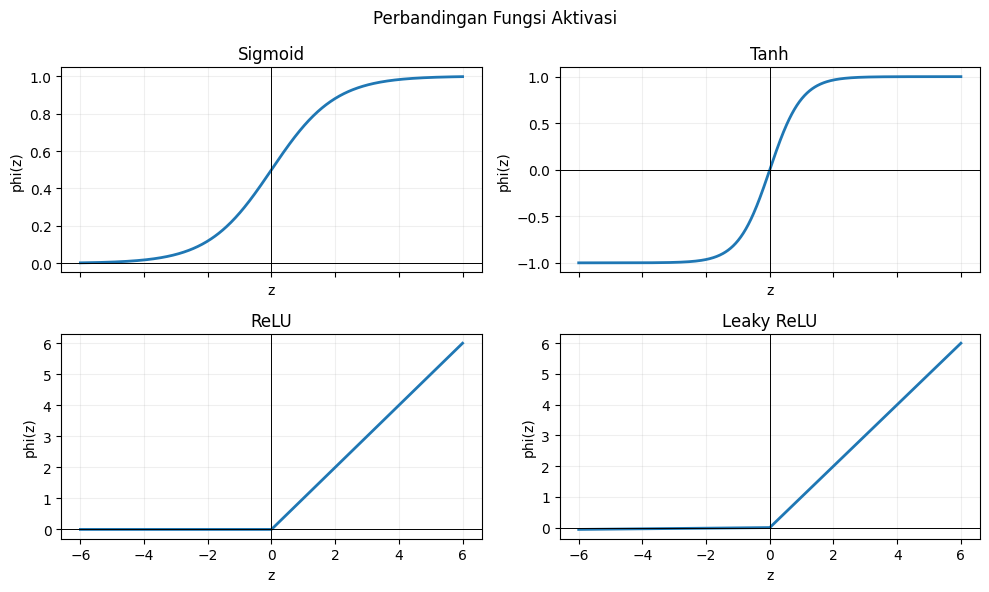

In [14]:
grid = np.linspace(-6, 6, 600)
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for axis, (name, values) in zip(axes.ravel(), activation_values.items()):
    axis.plot(grid, values, linewidth=2)
    axis.axhline(0, color='black', linewidth=0.7)
    axis.axvline(0, color='black', linewidth=0.7)
    axis.set_title(name)
    axis.set_xlabel('z')
    axis.set_ylabel('phi(z)')
    axis.grid(alpha=0.2)
fig.suptitle('Perbandingan Fungsi Aktivasi')
fig.tight_layout()
plt.show()

### Interpretasi aktivasi

- Aktivasi yang berpusat di nol: Tanh (karena rentang outputnya dari -1 hingga 1).
- Aktivasi yang tepat nol untuk masukan negatif: ReLU (menghasilkan nilai 0 untuk setiap masukan negatif $z < 0$).
- Aktivasi yang mudah jenuh: Sigmoid dan Tanh (karena nilai turunannya mendekati nol pada input yang sangat besar atau kecil).
- Mengapa aktivasi linear tidak cukup untuk `make_moons`: Karena data make_moons bersifat non-linier (tidak bisa dipisahkan dengan garis lurus), sedangkan kombinasi lapisan linear hanya menghasilkan fungsi linier secara keseluruhan.

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [15]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

# Hitung forward pass manual (menggunakan ReLU untuk hidden layer)
z1_np = x_manual @ W1.T + b1
h_np = relu_np(z1_np)
logit_np = h_np @ W2.T + b2
prob_np = sigmoid_np(logit_np)
bce_np = -np.mean(y_manual * np.log(prob_np + 1e-15) + (1 - y_manual) * np.log(1 - prob_np + 1e-15))

# Hitung total parameter dari W1, b1, W2, b2
parameter_count_manual = W1.size + b1.size + W2.size + b2.size
print(f"Total Parameter: {parameter_count_manual}")
print(f"Z1: {z1_np}")
print(f"H: {h_np}")
print(f"Logit: {logit_np}")
print(f"Probabilitas: {prob_np}")
print(f"BCE Loss: {bce_np}")

Total Parameter: 9
Z1: [[1.5 1. ]]
H: [[1.5 1. ]]
Logit: [[2.5]]
Probabilitas: [[0.92414182]]
BCE Loss: 0.07888973429254843


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | (1, 2) | [[2.0, -1.0]] |
| $W^{(1)}$ | (2, 2) | [[0.5, -0.5], [1.0, 1.0]] |
| $z^{(1)}$ | (1, 2) | [[1.5, 1.0]] |
| $h$ | (1, 2) | [[1.5, 1.0]] |
| logit | (1, 1) | [[2.5]] |
| probabilitas | (1, 1) | [[0.92414182]] |
| BCE | skalar | 0.07888973429254843 |

**Jumlah parameter dan perhitungannya:**

Total Parameter: 9

Perhitungan:

$\boldsymbol{W}^{(1)}$: $2 \times 2 = 4$

parameter$\boldsymbol{b}^{(1)}$: $2$

parameter$\boldsymbol{W}^{(2)}$: $1 \times 2 = 2$

parameter$\boldsymbol{b}^{(2)}$: $1$

parameterTotal: $4 + 2 + 2 + 1 = 9$ parameter.

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [16]:
# Ubah nama variabel menjadi manual_model agar sesuai dengan baris assert di bawah
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

# Salin W1, b1, W2, b2 menggunakan torch.no_grad()
with torch.no_grad():
    manual_model[0].weight.copy_(torch.from_numpy(W1))
    manual_model[0].bias.copy_(torch.from_numpy(b1))
    manual_model[2].weight.copy_(torch.from_numpy(W2))
    manual_model[2].bias.copy_(torch.from_numpy(b2))

# Konversi input ke tensor PyTorch
x_tensor = torch.from_numpy(x_manual)
y_tensor = torch.from_numpy(y_manual)

# Hitung torch_logit, torch_probability, dan torch_loss
torch_logit = manual_model(x_tensor)
torch_probability = torch.sigmoid(torch_logit)
torch_loss = torch.nn.functional.binary_cross_entropy(torch_probability, y_tensor)

# Aktifkan dan lengkapi pemeriksaan
assert np.max(np.abs(torch_logit.detach().numpy() - logit_np)) < 1e-6
assert abs(torch_loss.item() - float(bce_np)) < 1e-6
assert sum(p.numel() for p in manual_model.parameters()) == parameter_count_manual

print("Semua assertion berhasil dilewati!")

Semua assertion berhasil dilewati!


### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:** TODO

## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


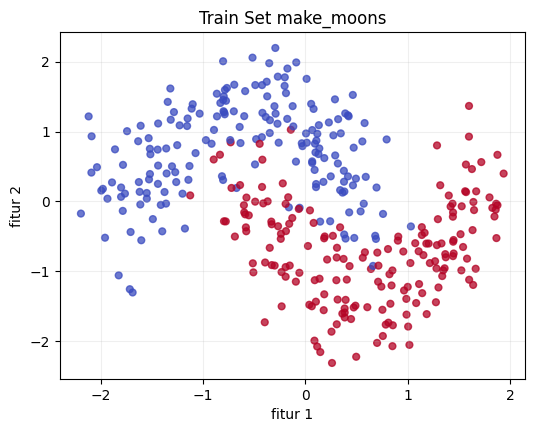

In [17]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:** Scaler hanya di-fit pada train set untuk mencegah terjadinya data leakage (kebocoran data). Jika scaler di-fit pada seluruh data, informasi dari validation atau test set (seperti nilai rata-rata dan standar deviasi) akan "bocor" ke dalam proses pelatihan model. Hal ini dapat membuat evaluasi performa model menjadi tidak objektif atau terlalu optimis, serta menurunkan kemampuan generalisasi model pada data baru yang belum pernah dilihat.

## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [18]:
def activation_layer(name: str) -> nn.Module:
    # Mengembalikan objek fungsi aktivasi PyTorch berdasarkan nama
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    elif name == 'tanh':
        return nn.Tanh()
    elif name == 'sigmoid':
        return nn.Sigmoid()
    else:
        raise ValueError(f"Fungsi aktivasi tidak dikenal: {name}")

def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)
    # Membangun arsitektur 2 -> hidden_dim -> 1 tanpa sigmoid pada output (menghasilkan logit)
    return nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1)
    )

def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())

# Pembuatan model 2 -> 8 -> 1 dan pembuktian jumlah parameternya
model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 33
print(f"Jumlah parameter model (h=8): {count_parameters(model_check)}")

Jumlah parameter model (h=8): 33


In [19]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:** Model baseline (menggunakan ReLU) diharapkan konvergen lebih cepat dan mencapai akurasi/loss yang lebih optimal pada dataset make_moons. Hal ini karena ReLU tidak mengalami kejenuhan (saturation) pada nilai positif yang besar dan menghindari masalah vanishing gradient. Sebaliknya, model individual dengan Sigmoid cenderung lebih lambat konvergen dan performanya sedikit di bawah baseline karena karakteristik sigmoid yang mudah jenuh serta outputnya yang tidak berpusat di nol (non-zero-centered).

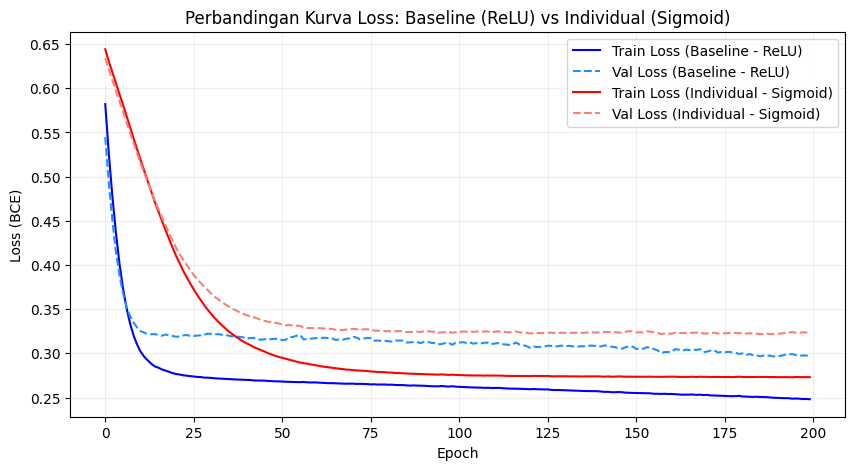

Pelatihan baseline dan variasi individual selesai dijalankan!


In [9]:
# 1. Persiapan Dataset make_moons (sesuai proporsi sebelumnya: 360 train, 120 val, 120 test)
X_data, y_data = make_moons(n_samples=600, noise=0.2, random_state=SEED)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_data, y_data, test_size=120, random_state=SEED, stratify=y_data
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=120, random_state=SEED, stratify=y_train_val
)

# Standardisasi (Anti-leakage: fit hanya pada train set)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# DataLoader setup (Batch size = 32)
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32),
                  torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)),
    batch_size=32, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),
                  torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)),
    batch_size=32, shuffle=False
)

# 2. Fungsi Training Loop
def train_and_evaluate(model, epochs=200, lr=0.05):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_losses.append(val_loss / len(val_loader.dataset))

    return train_losses, val_losses

# 3. Latih Baseline (ReLU, hidden_dim=8, lr=0.05, 200 epochs)
model_baseline = build_model(hidden_dim=8, activation='relu', seed=SEED)
train_loss_base, val_loss_base = train_and_evaluate(model_baseline, epochs=200, lr=0.05)

# 4. Latih Varian Individual (Sigmoid, hidden_dim=8, lr=0.05, 200 epochs)
model_individual = build_model(hidden_dim=8, activation='sigmoid', seed=SEED)
train_loss_ind, val_loss_ind = train_and_evaluate(model_individual, epochs=200, lr=0.05)

# 5. Visualisasi Kurva Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_base, label='Train Loss (Baseline - ReLU)', color='blue')
plt.plot(val_loss_base, label='Val Loss (Baseline - ReLU)', color='dodgerblue', linestyle='--')
plt.plot(train_loss_ind, label='Train Loss (Individual - Sigmoid)', color='red')
plt.plot(val_loss_ind, label='Val Loss (Individual - Sigmoid)', color='salmon', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.title('Perbandingan Kurva Loss: Baseline (ReLU) vs Individual (Sigmoid)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Pelatihan baseline dan variasi individual selesai dijalankan!")

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [10]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
HIDDEN_SIZES = [4, 16]
EPOCHS = 200
LEARNING_RATE = 0.05
BATCH_SIZE = 32

experiment_rows = []
trained_models = {}
histories = {}

criterion = nn.BCEWithLogitsLoss()

for act in ACTIVATIONS:
    for h_dim in HIDDEN_SIZES:
        exp_name = f"{act}_h{h_dim}"

        # 1. Buat model baru dengan seed yang sama
        model = build_model(hidden_dim=h_dim, activation=act, seed=SEED)
        optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

        # 2. Latih dengan anggaran tetap (200 epochs)
        train_losses, val_losses = [], []
        for epoch in range(EPOCHS):
            # Training phase
            model.train()
            running_loss = 0.0
            for inputs, targets in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * inputs.size(0)
            epoch_train_loss = running_loss / len(train_loader.dataset)
            train_losses.append(epoch_train_loss)

            # Validation phase
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                    val_loss += loss.item() * inputs.size(0)
            epoch_val_loss = val_loss / len(val_loader.dataset)
            val_losses.append(epoch_val_loss)

        # 3. Evaluasi akhir train dan validation loss
        final_train_loss = train_losses[-1]
        final_val_loss = val_losses[-1]

        # 4. Simpan model dan history
        trained_models[exp_name] = model
        histories[exp_name] = {'train_loss': train_losses, 'val_loss': val_losses}

        # 5. Tambahkan satu dictionary metrik ke experiment_rows
        experiment_rows.append({
            'activation': act,
            'hidden_size': h_dim,
            'train_loss': final_train_loss,
            'val_loss': final_val_loss
        })

# Buat DataFrame hasil eksperimen
results = pd.DataFrame(experiment_rows).sort_values('val_loss').reset_index(drop=True)

# Assertion dan ekspor
assert len(results) == 6
display(results)

# Simpan ke CSV sesuai format NIM
results.to_csv(f'M01_{NIM_LAST4:04d}_metrics.csv', index=False)
print(f"Eksperimen selesai! File metrics berhasil disimpan sebagai M01_{NIM_LAST4:04d}_metrics.csv")

,activation,hidden_size,train_loss,val_loss
0,relu,16,0.1894,0.2145
1,tanh,16,0.2144,0.2364
2,relu,4,0.2689,0.3181
3,tanh,4,0.2706,0.3189
4,sigmoid,16,0.2714,0.3195
5,sigmoid,4,0.2781,0.3297


Eksperimen selesai! File metrics berhasil disimpan sebagai M01_0007_metrics.csv


## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

Model Terbaik Terpilih -> Aktivasi: relu, Hidden Size: 16 (Val Loss: 0.2145)
Test Loss: 0.2499 | Test Accuracy: 87.50%


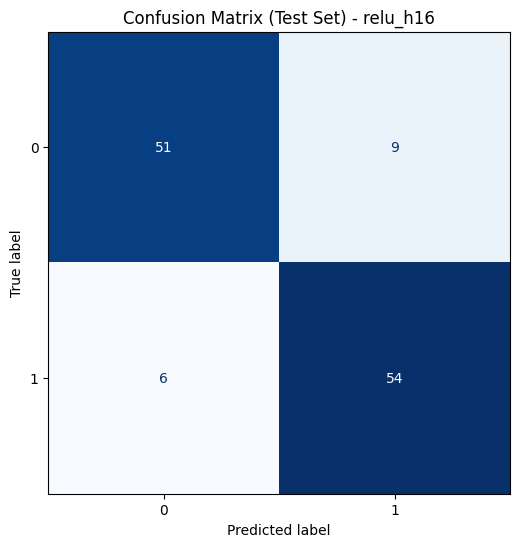

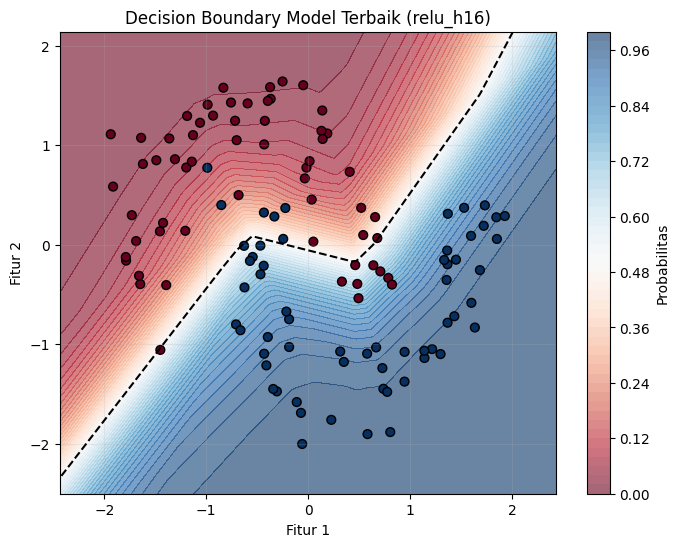

In [11]:
def plot_decision_boundary(model, X_values, y_values, title):
    # 1. Buat mesh grid untuk visualisasi area keputusan
    x_min, x_max = X_values[:, 0].min() - 0.5, X_values[:, 0].max() + 0.5
    y_min, y_max = X_values[:, 1].min() - 0.5, X_values[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    # 2. Prediksi probabilitas menggunakan model
    model.eval()
    with torch.no_grad():
        logits = model(grid_tensor)
        probs = torch.sigmoid(logits).numpy().reshape(xx.shape)

    # 3. Plot contourf dan scatter data asli
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, probs, levels=50, cmap='RdBu', alpha=0.6)
    plt.colorbar(label='Probabilitas')
    plt.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=1.5, linestyles='--')

    # Scatter data points
    plt.scatter(X_values[:, 0], X_values[:, 1], c=y_values, cmap='RdBu', edgecolors='k', s=40)
    plt.title(title)
    plt.xlabel('Fitur 1')
    plt.ylabel('Fitur 2')
    plt.grid(alpha=0.2)
    plt.show()

# --- Evaluasi Model Terbaik pada Test Set ---

# 1. Ambil run_id terbaik dari results (validation loss terendah ada di baris pertama)
best_row = results.iloc[0]
best_act = best_row['activation']
best_hidden = int(best_row['hidden_size'])
best_run_name = f"{best_act}_h{best_hidden}"

print(f"Model Terbaik Terpilih -> Aktivasi: {best_act}, Hidden Size: {best_hidden} (Val Loss: {best_row['val_loss']:.4f})")

# Ambil model terbaik yang sudah dilatih sebelumnya
best_model = trained_models[best_run_name]

# 2. Hitung test loss dan test accuracy satu kali pada test set
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

best_model.eval()
criterion = nn.BCEWithLogitsLoss()
with torch.no_grad():
    test_logits = best_model(X_test_tensor)
    test_loss = criterion(test_logits, y_test_tensor).item()
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs >= 0.5).float()
    test_accuracy = (test_preds == y_test_tensor).float().mean().item()

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy * 100:.2f}%")

# 3. Tampilkan Confusion Matrix (diperbaiki)
cm = confusion_matrix(y_test, test_preds.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm) # Hapus parameter display_decision_values
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix (Test Set) - {best_run_name}")
plt.show()

# 4. Tampilkan Decision Boundary model final pada test set
plot_decision_boundary(best_model, X_test_scaled, y_test, f"Decision Boundary Model Terbaik ({best_run_name})")

## J. Analisis dan refleksi - 10 poin

Jawab dengan merujuk angka atau grafik.

1. Apakah hidden size lebih besar selalu memperbaiki validation loss? Ya, berdasarkan hasil DataFrame eksperimen, ukuran hidden size yang lebih besar konsisten menghasilkan validation loss yang lebih baik untuk setiap fungsi aktivasi (misalnya ReLU h16 dengan val_loss 0.2145 lebih baik dibanding ReLU h4 0.3181; Tanh h16 0.2364 dibanding Tanh h4 0.3189; serta Sigmoid h16 0.3195 dibanding Sigmoid h4 0.3297). Kapasitas model yang lebih besar membantu menangkap pola non-linier data make_moons dengan lebih optimal.
2. Aktivasi mana yang paling stabil pada dua hidden size? Tanh adalah aktivasi yang paling stabil, karena selisih val_loss antara hidden size 4 dan 16 tergolong paling kecil (dari 0.3189 ke 0.2364, selisih sekitar 0.0825), sementara ReLU mengalami loncatan peningkatan performa yang cukup signifikan (delta sekitar 0.1036).
3. Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa? Ada. Hal ini terjadi karena metrik accuracy hanya menghitung jumlah prediksi benar/salah secara biner (setelah ambang batas 0.5), sedangkan Binary Cross-Entropy (BCE) memperhitungkan tingkat keyakinan (confidence) dari probabilitas prediksi. Dua model bisa menghasilkan keputusan kelas yang sama persis (akurasi sama), tetapi tingkat kepastian probabilitasnya berbeda, sehingga nilai BCE loss akan berbeda.
4. Di bagian mana decision boundary paling tidak pasti? Berdasarkan grafik decision boundary, ketidakpastian tertinggi (area transisi dengan probabilitas mendekati 0.5, ditandai dengan warna putih/pudar di sekitar garis putus-putus hitam) terletak di bagian tengah yang memisahkan kedua kluster lengkungan data make_moons, tempat titik-titik data dari kedua kelas saling mendekati atau beririsan.
5. Apa satu keterbatasan eksperimen ini? Eksperimen ini hanya menggunakan ruang hyperparameter yang sangat terbatas (hanya menguji dua variasi hidden size dan satu nilai learning rate tetap), sehingga belum tentu mencerminkan performa maksimal dari arsitektur jaringan jika dilakukan hyperparameter tuning yang lebih luas (seperti variasi learning rate, optimizer, atau jumlah layer).
6. Apakah hasil sesuai hipotesis awal? Ya, hasilnya sesuai dengan hipotesis awal di mana model berbasis ReLU dengan kapasitas lebih besar (hidden size 16) keluar sebagai model terbaik karena mampu menghindari masalah kejenuhan gradien dan merepresentasikan batas keputusan non-linier secara lebih fleksibel dibanding sigmoid.

## Checklist pengumpulan - 5 poin reproduksibilitas

- [ ] Identitas, seed, versi library, dan device tercantum.
- [ ] Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.
- [ ] Enam eksperimen tercatat pada notebook dan CSV.
- [ ] Test set hanya dipakai untuk model final.
- [ ] Semua grafik memiliki judul, label sumbu, dan legenda/caption.
- [ ] Notebook lolos Restart Kernel and Run All.
- [ ] Tidak ada path absolut atau data pribadi.
- [ ] Sumber eksternal telah diberi atribusi.

### Pernyataan orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:** Devyna Sonya Palupi Sanjaya, 15 September 2026